In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define dataset path
DATA_DIR = Path("../data")

# Get class names
classes = os.listdir(DATA_DIR / "training")
print("Classes found:", classes)

# Count images per class
print("\nTraining images per class:")
for cls in classes:
    count = len(os.listdir(DATA_DIR / "training" / cls))
    print(f"  {cls}: {count} images")

print("\nTesting images per class:")
for cls in classes:
    count = len(os.listdir(DATA_DIR / "testing" / cls))
    print(f"  {cls}: {count} images")

Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training images per class:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing images per class:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


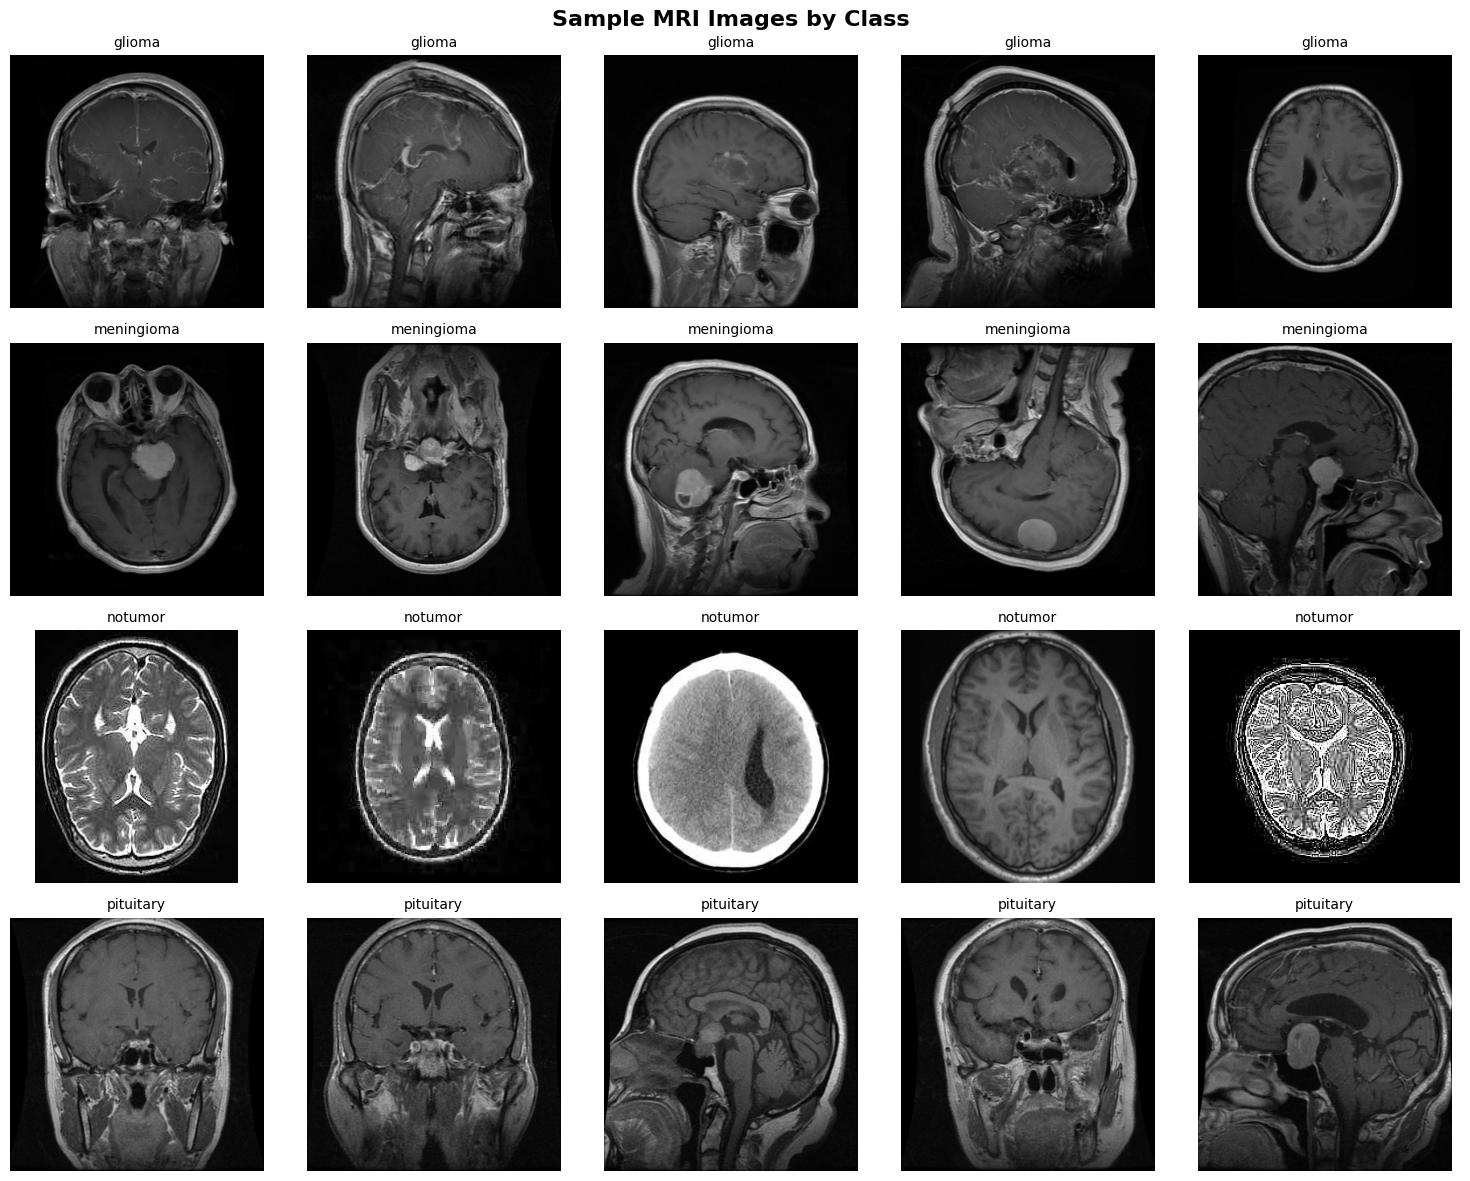

✅ Sample images saved!


In [ ]:
from PIL import Image

# Display sample images from each class
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle("Sample MRI Images by Class", fontsize=16, fontweight='bold')

for row, cls in enumerate(classes):
    class_path = DATA_DIR / "training" / cls
    images = os.listdir(class_path)[:5]  # first 5 images
    
    for col, img_name in enumerate(images):
        img = Image.open(class_path / img_name)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("../notebooks/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Sample images saved!")

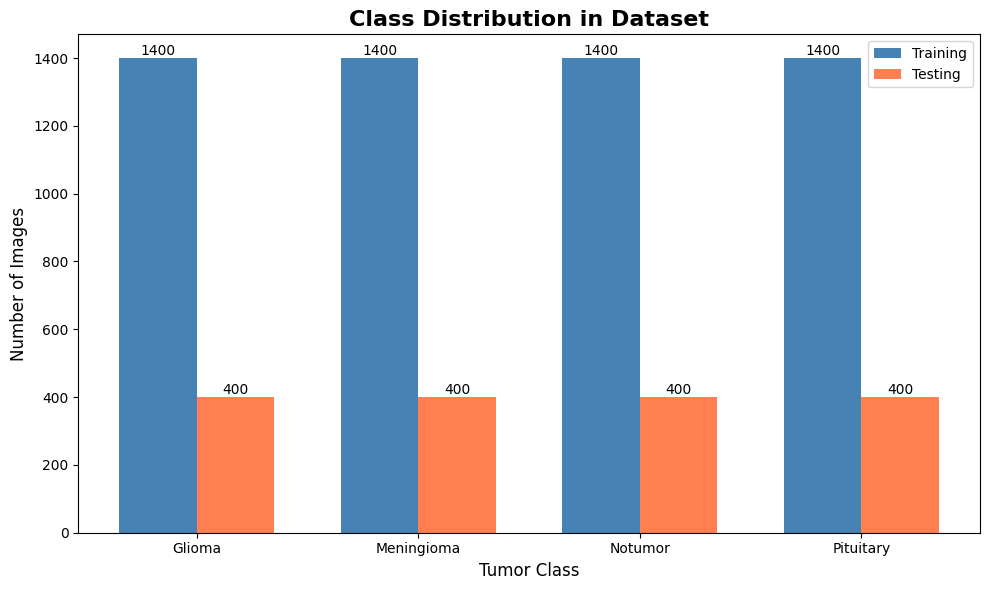

✅ Class distribution chart saved!


In [ ]:
# Class distribution bar chart
train_counts = []
test_counts = []

for cls in classes:
    train_counts.append(len(os.listdir(DATA_DIR / "training" / cls)))
    test_counts.append(len(os.listdir(DATA_DIR / "testing" / cls)))

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_counts, width, label='Training', color='steelblue')
bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', color='coral')

ax.set_title('Class Distribution in Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Tumor Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in classes])
ax.legend()

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("../notebooks/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Class distribution chart saved!")

In [ ]:
# Analyze image sizes and properties
widths, heights = [], []

for cls in classes:
    class_path = DATA_DIR / "training" / cls
    for img_name in os.listdir(class_path)[:50]:  # check 50 images per class
        img = Image.open(class_path / img_name)
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(" Image Size Analysis:")
print(f"  Width  → min: {min(widths)}px  max: {max(widths)}px  avg: {int(np.mean(widths))}px")
print(f"  Height → min: {min(heights)}px  max: {max(heights)}px  avg: {int(np.mean(heights))}px")

# Check color modes
print("\n Image Color Modes (first 3 per class):")
for cls in classes:
    class_path = DATA_DIR / "training" / cls
    images = os.listdir(class_path)[:3]
    modes = [Image.open(class_path / img).mode for img in images]
    print(f"  {cls}: {modes}")

📊 Image Size Analysis:
  Width  → min: 192px  max: 900px  avg: 465px
  Height → min: 183px  max: 741px  avg: 466px

🎨 Image Color Modes (first 3 per class):
  glioma: ['L', 'L', 'L']
  meningioma: ['RGB', 'RGB', 'L']
  notumor: ['RGB', 'RGB', 'RGB']
  pituitary: ['RGB', 'RGB', 'RGB']


In [ ]:
# Summary of what we learned and what we'll do
print(" Dataset Summary:")
print(f"  Classes        : {classes}")
print(f"  Train images   : {sum(train_counts)} total ({train_counts[0]} per class)")
print(f"  Test images    : {sum(test_counts)} total ({test_counts[0]} per class)")
print(f"  Image sizes    : vary from 192px to 900px")
print(f"  Color modes    : mixed (grayscale + RGB)")

print("\n Preprocessing Plan:")
print("  1. Resize all images to 224x224 (EfficientNet standard)")
print("  2. Convert all images to RGB (fix grayscale inconsistency)")
print("  3. Normalize pixel values to [0, 1]")
print("  4. Apply data augmentation on training set")

print("\n Model Plan:")
print("  - EfficientNetB0 pretrained on ImageNet")
print("  - Fine-tune on our brain tumor dataset")
print("  - Expected accuracy: 95%+")

📋 Dataset Summary:
  Classes        : ['glioma', 'meningioma', 'notumor', 'pituitary']
  Train images   : 5600 total (1400 per class)
  Test images    : 1600 total (400 per class)
  Image sizes    : vary from 192px to 900px
  Color modes    : mixed (grayscale + RGB)

✅ Preprocessing Plan:
  1. Resize all images to 224x224 (EfficientNet standard)
  2. Convert all images to RGB (fix grayscale inconsistency)
  3. Normalize pixel values to [0, 1]
  4. Apply data augmentation on training set

🧠 Model Plan:
  - EfficientNetB0 pretrained on ImageNet
  - Fine-tune on our brain tumor dataset
  - Expected accuracy: 95%+
